## To look at distribution of tripos cells in Radbot horizontal data


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib as Path 


In [2]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/D20230626T133109_IFCB110_merged_keepzero.csv")


In [5]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/DenseAlex/nauset/merged")
output_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/DenseAlex/Alex_master.csv")

score_col = "Alexandrium_catenella"
alpha = 0.9

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] > alpha].copy()

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} > {alpha}")
print(f"Saved to {output_csv}")

Matched 16343 rows with Alexandrium_catenella > 0.9
Saved to /Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/DenseAlex/Alex_master.csv


In [10]:
df = pd.read_csv("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/DenseAlex/Alex_master.csv")


In [11]:
print(df.head())    


                              pid  Alexandrium_catenella  \
0  D20240402T115529_IFCB124_00052                 0.9420   
1  D20240402T115529_IFCB124_00133                 0.9663   
2  D20240402T115529_IFCB124_00143                 0.9165   
3  D20240402T115529_IFCB124_00149                 0.9390   
4  D20240402T115529_IFCB124_00185                 0.9995   

   Alexandrium_catenella_TAG_2cell_TAG_chain  \
0                                   0.005627   
1                                   0.028950   
2                                   0.034880   
3                                   0.004047   
4                                   0.000296   

   Alexandrium_catenella_TAG_4cell_TAG_chain  \
0                               0.000000e+00   
1                               0.000000e+00   
2                               6.000000e-08   
3                               0.000000e+00   
4                               0.000000e+00   

   Alexandrium_catenella_TAG_dividing  Alexandrium_catenella_

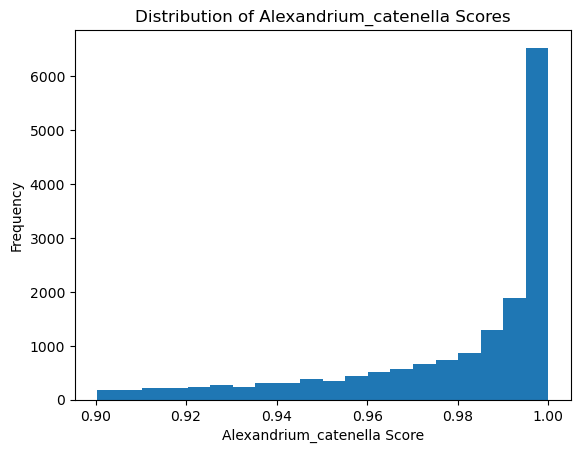

In [12]:
plt.hist(df["Alexandrium_catenella"], bins=20)
plt.xlabel("Alexandrium_catenella Score")
plt.ylabel("Frequency")
plt.title("Distribution of Alexandrium_catenella Scores")
plt.show()  

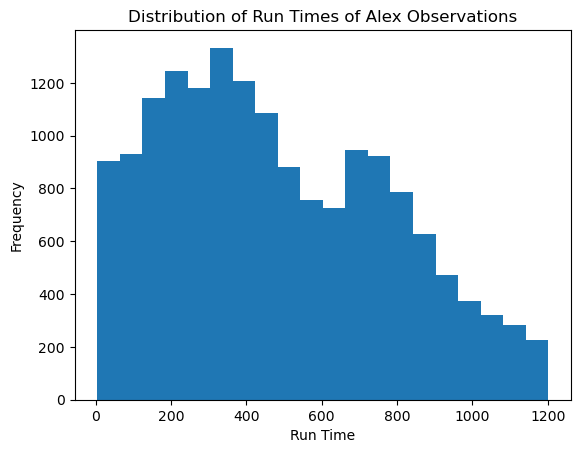

In [13]:
plt.hist(df["RunTime"], bins=20)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of Alex Observations")
#plt.savefig("../Figs/TriposRunTimeDistribution.png")
plt.show()  

KS statistic: 0.16255592827988774
p-value: 0.0


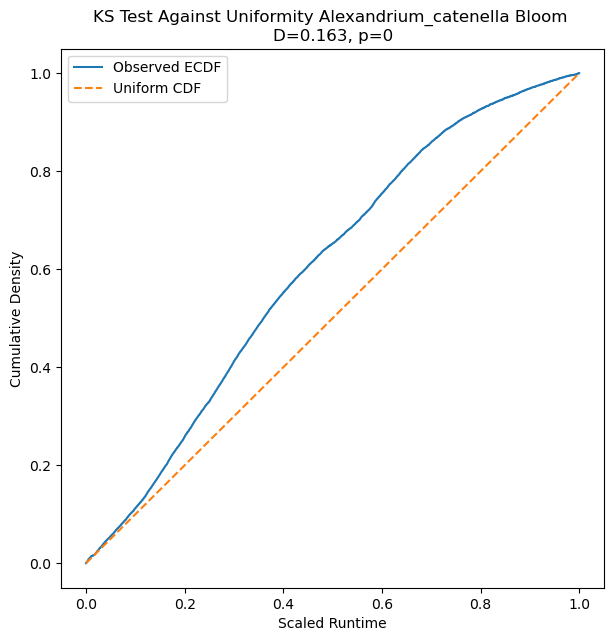

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Alexandrium_catenella Bloom \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/DenseAlexDay/KS_test_alex.png", dpi=300)

plt.show()

## Is this different from just all rois?


Loaded D20260603T192533_IFCB124_adc_only.csv: 5981 values
Loaded D20260603T224311_IFCB124_adc_only.csv: 4424 values
Loaded D20260604T025829_IFCB124_adc_only.csv: 3987 values
Loaded D20260604T003915_IFCB124_adc_only.csv: 4688 values
Loaded D20260604T012540_IFCB124_adc_only.csv: 4395 values
Loaded D20260604T010227_IFCB124_adc_only.csv: 4614 values
Loaded D20260603T183908_IFCB124_adc_only.csv: 6492 values
Loaded D20260603T232937_IFCB124_adc_only.csv: 5756 values
Loaded D20260603T221959_IFCB124_adc_only.csv: 5164 values
Loaded D20260603T215647_IFCB124_adc_only.csv: 5218 values
Loaded D20260604T023516_IFCB124_adc_only.csv: 3993 values
Loaded D20260604T014852_IFCB124_adc_only.csv: 4334 values
Loaded D20260603T181555_IFCB124_adc_only.csv: 6860 values
Loaded D20260603T204708_IFCB124_adc_only.csv: 5611 values
Loaded D20260604T021204_IFCB124_adc_only.csv: 4093 values
Loaded D20260603T235250_IFCB124_adc_only.csv: 5125 values
Loaded D20260603T230624_IFCB124_adc_only.csv: 4008 values
Loaded D202606

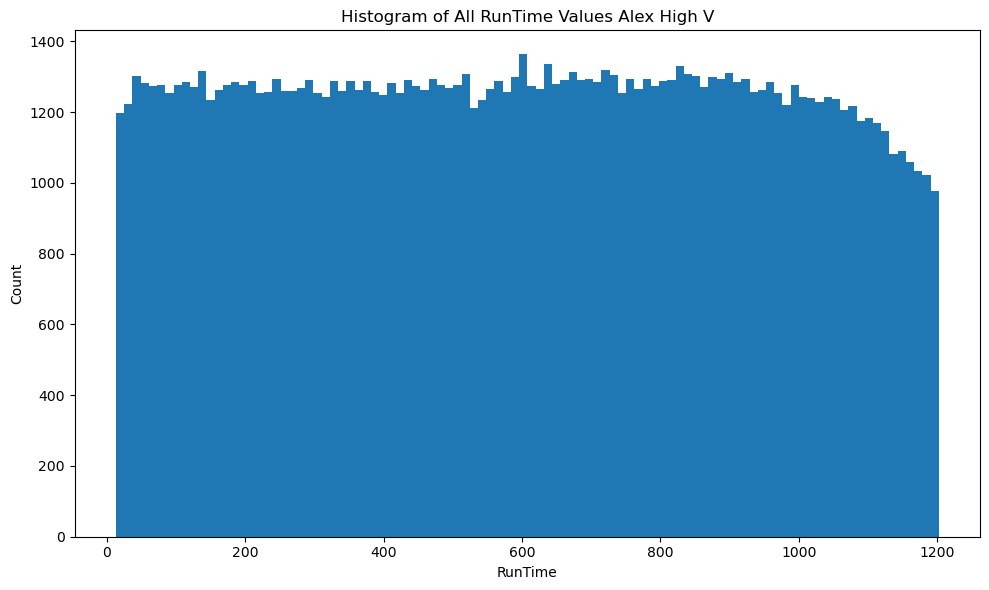

In [6]:

# -----------------------------
# User inputs
# -----------------------------

data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jatafixed/merged")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(runtime_series, bins=100)

plt.xlabel("RunTime")
plt.ylabel("Count")
plt.title("Histogram of All RunTime Values Alex High V")

plt.tight_layout()
#plt.savefig("../Figs/dilExp/AlexRunTimesHist.png")
plt.show()

KS statistic: 0.0686593455329293
p-value: 0.0


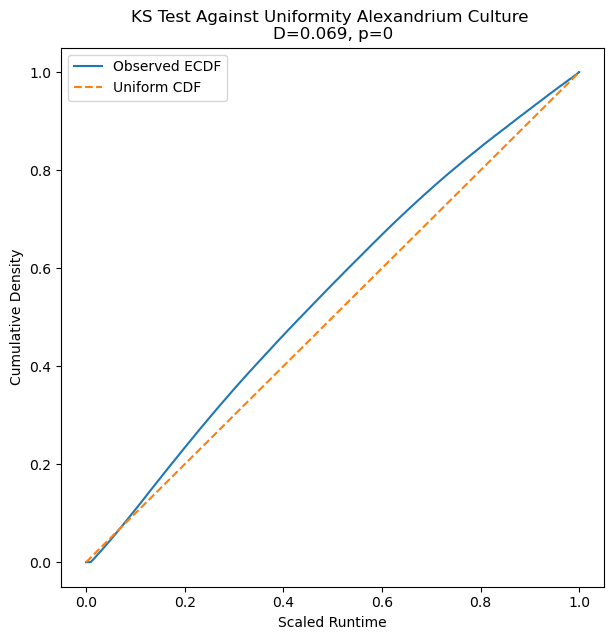

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(runtime_series)

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Alexandrium Culture \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/dilExp/KSTest_AlexHighV.png", dpi=300)

plt.show()

## Creating an outgroup there is no obvious other species but basically everything that isnt tripos is small and rare 
 Just change logic to select things that are less than alpha 0.9 of class score

In [2]:
# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
output_csv = Path("../IFCBData/SeaTrac/subsampled/not_tripos_master.csv")

score_col = "Tripos_muelleri"
alpha = 0.9

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] < alpha].copy() # Get rows where Tripos_muelleri <= 0.9 so not tripos

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} < {alpha}")
print(f"Saved to {output_csv}")

Matched 33841 rows with Tripos_muelleri < 0.9
Saved to ../IFCBData/SeaTrac/subsampled/not_tripos_master.csv


In [26]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/not_tripos_master.csv")
print(df.head())

   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         3          3  0.004349  18.182823  18.206510     0.170154   
1         6          6 -0.000374  55.007388  55.032044     0.426721   
2         7          7 -0.001228  57.129065  57.152752     0.510755   
3         8          8  0.016707  68.979647  69.004826     0.597971   
4        10         10 -0.004710  85.809036  85.832830     0.768084   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  ...         fiber  \
0         0.084651        0.075151        1         60  ...  8.100000e-06   
1         0.085816        0.227522        1         76  ...  6.510000e-05   
2         0.084034        0.236008        1        140  ...  6.000000e-08   
3         0.087216        0.285029        1         92  ...  6.000000e-08   
4         0.082303        0.354436        1         52  ...  8.820000e-05   

   fiber_TAG_external_detritus  flagellate flagellate_morphotype1  \
0                 8.000000e-07    0.02260

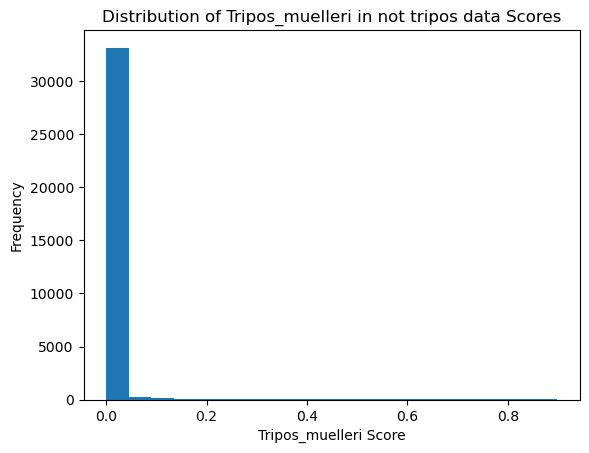

In [27]:
plt.hist(df["Tripos_muelleri"], bins=20)
plt.xlabel("Tripos_muelleri Score")
plt.ylabel("Frequency")
plt.title("Distribution of Tripos_muelleri in not tripos data Scores")
plt.show()  

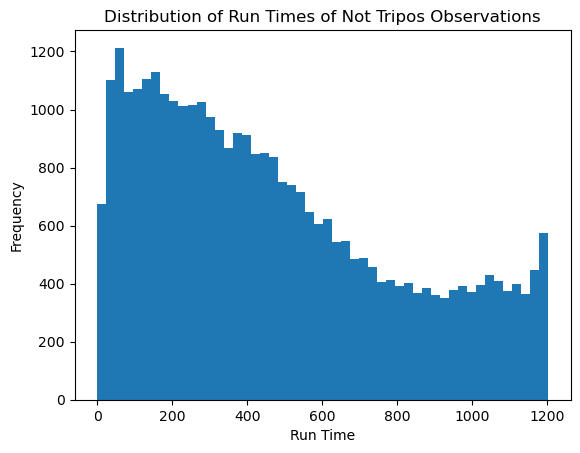

In [28]:
plt.hist(df["RunTime"], bins=50)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of Not Tripos Observations")
#plt.savefig("../Figs/Radbot_ios_Subsample/NotTriposRunTimeDistribution.png", dpi=300)
plt.show()  

KS statistic: 0.1854064432779896
p-value: 0.0


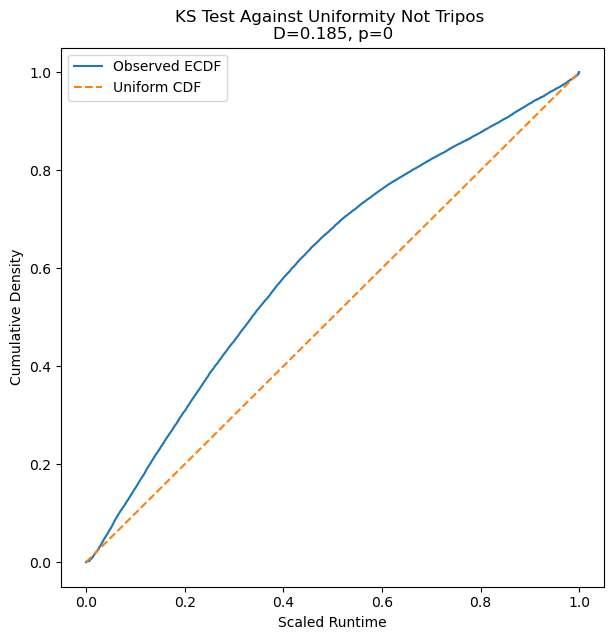

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Not Tripos \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Radbot_ios_Subsample/KS_test_NOT_Tripos.png", dpi=300)

plt.show()

### I would like to create an outgroup that is just based on size for the tripos one becyase there is some things that are broken and detritus that might be not called tripos but would settle


In [35]:
## sweep through files in directory and calculate roi area

from pathlib import Path
import pandas as pd

data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
file_pattern = "*.csv"

for file in data_dir.glob(file_pattern):

    print(f"Processing {file.name}")

    df = pd.read_csv(file)

    if "RoiHeight" not in df.columns:
        print(f"Skipping {file.name}: missing column RoiHeight")
        continue

    if "RoiWidth" not in df.columns:
        print(f"Skipping {file.name}: missing column RoiWidth")
        continue

    df["RoiArea"] = df["RoiHeight"] * df["RoiWidth"]

    # overwrite original file
    df.to_csv(file, index=False)

print("Done.")

Processing D20230627T001537_IFCB110_merged_keepzero.csv
Processing D20230709T120912_IFCB110_merged_keepzero.csv
Processing D20230704T121818_IFCB110_merged_keepzero.csv
Processing D20230717T062247_IFCB110_merged_keepzero.csv
Processing D20230706T061014_IFCB110_merged_keepzero.csv
Processing D20230708T000552_IFCB110_merged_keepzero.csv
Processing D20230709T001755_IFCB110_merged_keepzero.csv
Processing D20230710T180254_IFCB110_merged_keepzero.csv
Processing D20230716T180450_IFCB110_merged_keepzero.csv
Processing D20230718T002220_IFCB110_merged_keepzero.csv
Processing D20230706T213722_IFCB110_merged_keepzero.csv
Processing D20230713T001301_IFCB110_merged_keepzero.csv
Processing D20230714T002134_IFCB110_merged_keepzero.csv
Processing D20230718T121652_IFCB110_merged_keepzero.csv
Processing D20230629T181525_IFCB110_merged_keepzero.csv
Processing D20230703T014826_IFCB110_merged_keepzero.csv
Processing D20230704T000026_IFCB110_merged_keepzero.csv
Processing D20230708T061456_IFCB110_merged_keepz

In [44]:
# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
output_csv = Path("../IFCBData/SeaTrac/subsampled/small_RoiArea_master.csv")

score_col = "RoiArea"
alpha = 20000

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] < alpha].copy() # Get rows where RoiArea < 40000 so small particles

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} < {alpha}")
print(f"Saved to {output_csv}")

Matched 28903 rows with RoiArea < 20000
Saved to ../IFCBData/SeaTrac/subsampled/small_RoiArea_master.csv


In [50]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/small_RoiArea_master.csv")
print(df[df["RoiArea"] == 0].count())


trigger#              8235
RoiNumber             8235
PMTB                  8235
ADCtime               8235
RunTime               8235
                      ... 
pollen_spikey_dino    8235
unknown2              8235
RoiArea               8235
source_file           8235
source_path           8235
Length: 159, dtype: int64


In [ ]:
## remove zero rois
df_nonzero = df[df["RoiArea"] > 0]

In [53]:
print(df_nonzero['RoiArea'].describe())

count    20668.000000
mean      7268.395200
std       3666.704818
min       2912.000000
25%       4800.000000
50%       5984.000000
75%       8736.000000
max      19968.000000
Name: RoiArea, dtype: float64


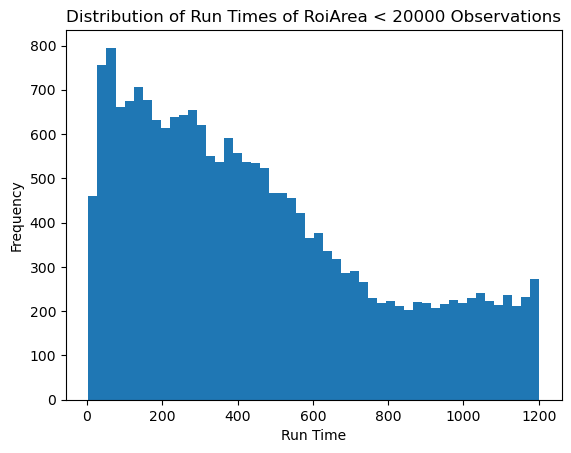

In [54]:
plt.hist(df_nonzero["RunTime"], bins=50)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of RoiArea < 20000 Observations")
#plt.savefig("../Figs/Radbot_ios_Subsample/NotTriposRunTimeDistribution.png", dpi=300)
plt.show()  

KS statistic: 0.20623168380895235
p-value: 0.0


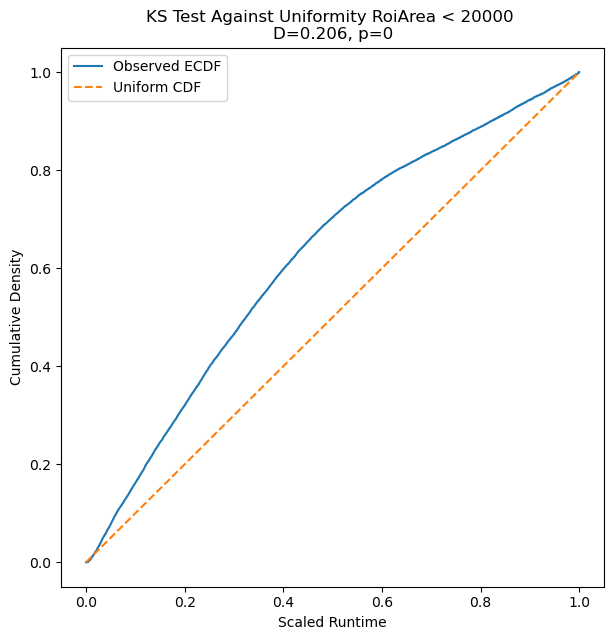

In [55]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(df_nonzero["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity RoiArea < 20000 \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Radbot_ios_Subsample/KS_test_NOT_Tripos.png", dpi=300)

plt.show()